In [14]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

# 分類名（dog／cat）をリストとして格納する
class_names = train_dataset.class_names
class_names



Found 300 files belonging to 2 classes.


Found 100 files belonging to 2 classes.


['cat', 'dog']

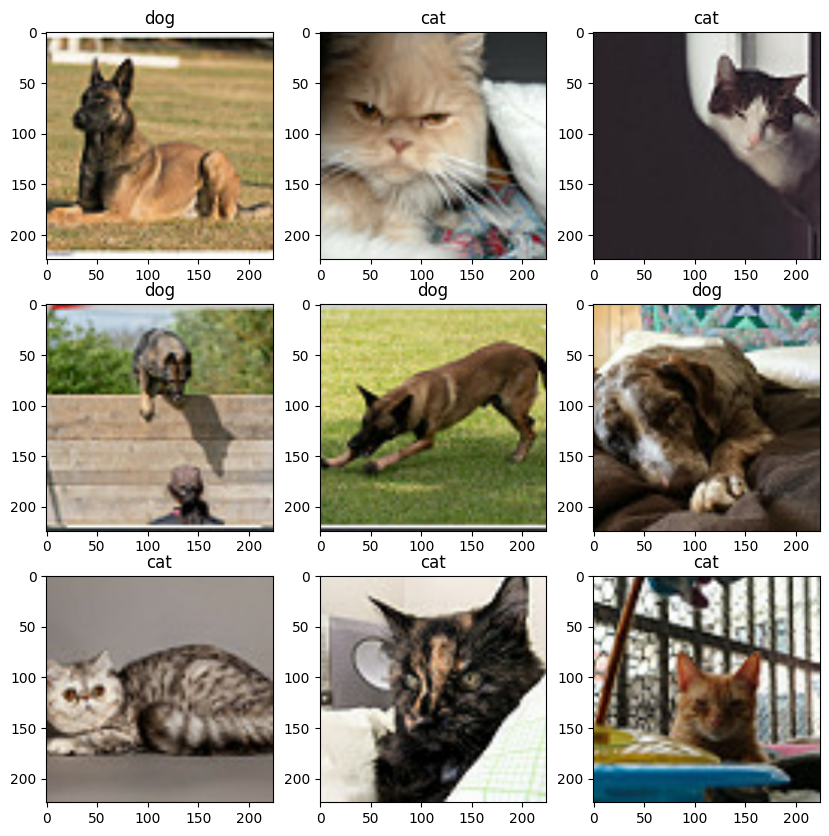

In [15]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [17]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label


# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)



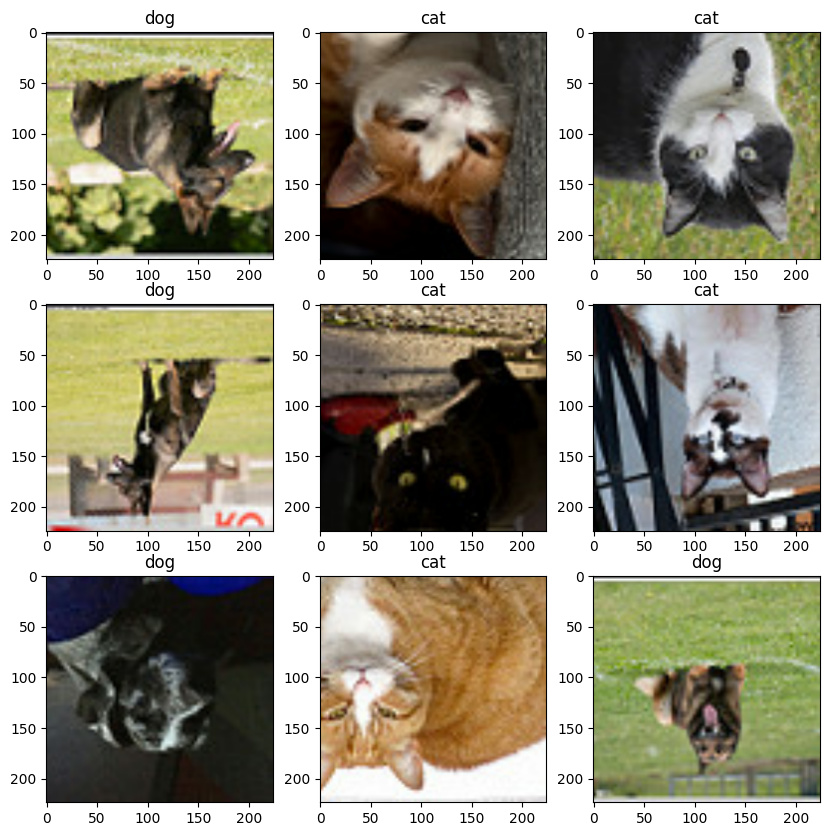

In [18]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [19]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False


# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])


# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])


# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 232ms/step - accuracy: 0.7894 - loss: 0.4529
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 238ms/step - accuracy: 0.9217 - loss: 0.2194
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 0.9406 - loss: 0.1731
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - accuracy: 0.9583 - loss: 0.1401
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - accuracy: 0.9694 - loss: 0.1158
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 0.9728 - loss: 0.1023
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 0.9800 - loss: 0.0896
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 230ms/step - accuracy: 0.9806 - loss: 0.0821
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 237ms/step - accuracy: 0.9878 - loss: 0.0719
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - accuracy: 0.9894 - loss: 0.0652
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - accuracy: 0.9894 - loss: 0.0601
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14

In [20]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

print(pred_data)  #1.8004324e-04というのは0.18004324という意味らしい


# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step
[[2.9068471e-05]
 [3.3668606e-04]
 [2.1641783e-05]
 [5.9282954e-04]
 [4.9377838e-04]
 [1.6126214e-04]
 [2.5973984e-04]
 [3.4562251e-04]
 [1.1646692e-05]
 [2.8074256e-04]
 [2.6549347e-05]
 [1.6452577e-03]
 [2.9441165e-03]
 [3.6022134e-04]
 [3.4588018e-05]
 [2.2334630e-06]
 [6.0214632e-05]
 [1.3027435e-04]
 [1.7472901e-03]
 [1.0419405e-03]
 [8.3605740e-03]
 [9.6303113e-02]
 [8.8323979e-04]
 [3.4643535e-04]
 [1.2360133e-01]
 [8.5605361e-04]
 [7.0631655e-04]
 [4.1939775e-04]
 [6.1029391e-03]
 [1.0273273e-04]
 [6.9324905e-04]
 [4.3116394e-01]
 [2.4589480e-04]
 [6.5592403e-04]
 [3.3028251e-03]
 [7.7894777e-01]
 [3.2690612e-03]
 [7.4169482e-04]
 [1.8542279e-02]
 [2.5440898e-04]
 [2.2507273e-04]
 [3.4195176e-04]
 [2.0653827e-02]
 [1.2435811e-04]
 [2.5111160e-04]
 [6.6066831e-02]
 [2.7845538e-04]
 [5.0843402e-04]
 [4.6498538e-03]
 [1.2997209e-04]
 [9.9690300e-01]
 [9.9934512e-01]
 [9.9992019e-01]
 [9.9930394e-01]
 [9.9923217e-01]
 [2.8290638e-01]
 [9.99978

[0.058716967701911926, 0.9700000286102295]